# Candle Image Classification using Deep Learning

## Problem Definition
Classify candle images by orientation (Up vs Down) using convolutional neural networks.

## Goals
1. Build and train a CNN model to classify candle orientations
2. Evaluate model performance using accuracy, precision, recall, and F1-score
3. Visualize predictions and analyze model behavior

## 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.models import resnet18
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
from PIL import Image
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Define Data Paths

Set up paths for Train/Test and Down/Up folders.

In [2]:
# Define base directory
base_dir = "C:\\TRU\\Term 4 Winter\\Integrated Practice III\\Project\\CandleStickClassification\\Data"

# Define individual paths for each subset
train_up = os.path.join(base_dir, 'Train', 'Up')
train_down = os.path.join(base_dir, 'Train', 'Down')
test_up = os.path.join(base_dir, 'Test', 'Up')
test_down = os.path.join(base_dir, 'Test', 'Down')

print('Data paths:')
print(f'Train Up: {train_up}')
print(f'Train Down: {train_down}')
print(f'Test Up: {test_up}')
print(f'Test Down: {test_down}')

Data paths:
Train Up: C:\TRU\Term 4 Winter\Integrated Practice III\Project\CandleStickClassification\Data\Train\Up
Train Down: C:\TRU\Term 4 Winter\Integrated Practice III\Project\CandleStickClassification\Data\Train\Down
Test Up: C:\TRU\Term 4 Winter\Integrated Practice III\Project\CandleStickClassification\Data\Test\Up
Test Down: C:\TRU\Term 4 Winter\Integrated Practice III\Project\CandleStickClassification\Data\Test\Down


## 3. Data Exploration

Count images in each folder.

In [3]:
# Count images in each folder
paths = {'Train Up': train_up, 'Train Down': train_down, 'Test Up': test_up, 'Test Down': test_down}

print('Image counts:')
for name, path in paths.items():
    if os.path.isdir(path):
        count = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        print(f'{name}: {count} images')
    else:
        print(f'{name}: Path not found!')

Image counts:
Train Up: 809 images
Train Down: 624 images
Test Up: 194 images
Test Down: 157 images


## 4. Visualize Sample Images

Display sample images from both orientations.

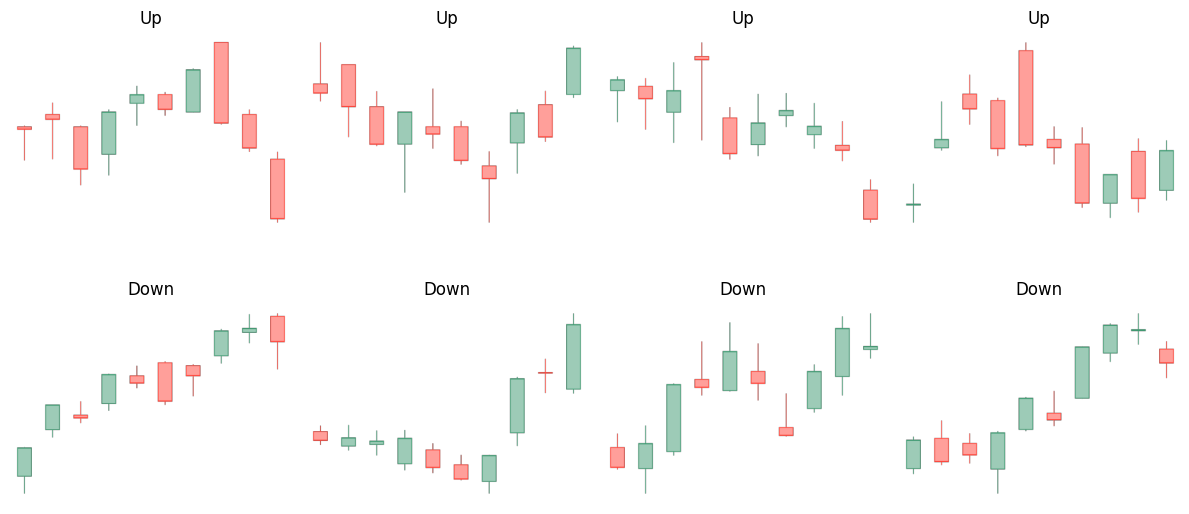

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Show Up samples
up_images = [f for f in os.listdir(train_up) if f.endswith(('.jpg', '.jpeg', '.png'))][:4]
for idx, img_file in enumerate(up_images):
    img_path = os.path.join(train_up, img_file)
    img = Image.open(img_path)
    axes[0, idx].imshow(img)
    axes[0, idx].set_title('Up')
    axes[0, idx].axis('off')

# Show Down samples
down_images = [f for f in os.listdir(train_down) if f.endswith(('.jpg', '.jpeg', '.png'))][:4]
for idx, img_file in enumerate(down_images):
    img_path = os.path.join(train_down, img_file)
    img = Image.open(img_path)
    axes[1, idx].imshow(img)
    axes[1, idx].set_title('Down')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

## 5. Create Custom Dataset Class

Define a PyTorch Dataset class that loads images from individual folders.

In [5]:
class CandleDataset(Dataset):
    def __init__(self, folder_up, folder_down, transform=None):
        """
        Args:
            folder_up: Path to folder containing 'Up' oriented candles
            folder_down: Path to folder containing 'Down' oriented candles
            transform: Optional image transformations
        """
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Load Up images (label=1)
        if os.path.isdir(folder_up):
            for img_file in os.listdir(folder_up):
                if img_file.endswith(('.jpg', '.jpeg', '.png')):
                    self.images.append(os.path.join(folder_up, img_file))
                    self.labels.append(1)  # Up
        
        # Load Down images (label=0)
        if os.path.isdir(folder_down):
            for img_file in os.listdir(folder_down):
                if img_file.endswith(('.jpg', '.jpeg', '.png')):
                    self.images.append(os.path.join(folder_down, img_file))
                    self.labels.append(0)  # Down
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

print('CandleDataset class created')

CandleDataset class created


## 6. Data Preprocessing and Augmentation

Define image transformations for training and testing.

In [6]:
# Define transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = CandleDataset(train_up, train_down, transform=train_transform)
test_dataset = CandleDataset(test_up, test_down, transform=test_transform)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Batch size: {batch_size}')

Training samples: 1433
Test samples: 351
Batch size: 32


## 7. Model Definition

Use ResNet18 pre-trained on ImageNet for binary classification.

In [7]:
# Load pre-trained ResNet18
model = resnet18(pretrained=True)

# Freeze early layers for transfer learning
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 2)

# Unfreeze final layer for fine-tuning
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
print('ResNet18 model loaded for binary classification (Down/Up)')

ResNet18 model loaded for binary classification (Down/Up)


## 8. Training Setup

Define loss function, optimizer, and training loop.

In [8]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(train_loader), correct / total

def evaluate(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(test_loader), correct / total

print('Training functions defined')

Training functions defined


## 9. Train the Model

Train for multiple epochs tracking training and test metrics.

In [9]:
num_epochs = 15
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
          f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

print('\nTraining completed')

Epoch [1/15] - Train Loss: 0.7400, Train Acc: 0.5318 | Test Loss: 0.6867, Test Acc: 0.5413
Epoch [2/15] - Train Loss: 0.7064, Train Acc: 0.5422 | Test Loss: 0.6896, Test Acc: 0.5328
Epoch [3/15] - Train Loss: 0.7067, Train Acc: 0.5450 | Test Loss: 0.7085, Test Acc: 0.5670
Epoch [4/15] - Train Loss: 0.7119, Train Acc: 0.5464 | Test Loss: 0.6925, Test Acc: 0.5413
Epoch [5/15] - Train Loss: 0.7044, Train Acc: 0.5304 | Test Loss: 0.7167, Test Acc: 0.5670
Epoch [6/15] - Train Loss: 0.7076, Train Acc: 0.5380 | Test Loss: 0.6898, Test Acc: 0.5470
Epoch [7/15] - Train Loss: 0.6943, Train Acc: 0.5506 | Test Loss: 0.6905, Test Acc: 0.5299
Epoch [8/15] - Train Loss: 0.6970, Train Acc: 0.5485 | Test Loss: 0.6911, Test Acc: 0.5584
Epoch [9/15] - Train Loss: 0.6889, Train Acc: 0.5590 | Test Loss: 0.6907, Test Acc: 0.5385
Epoch [10/15] - Train Loss: 0.6848, Train Acc: 0.5583 | Test Loss: 0.6911, Test Acc: 0.5271
Epoch [11/15] - Train Loss: 0.6897, Train Acc: 0.5541 | Test Loss: 0.6911, Test Acc: 0.52

## 10. Plot Training History

Visualize loss and accuracy over epochs.

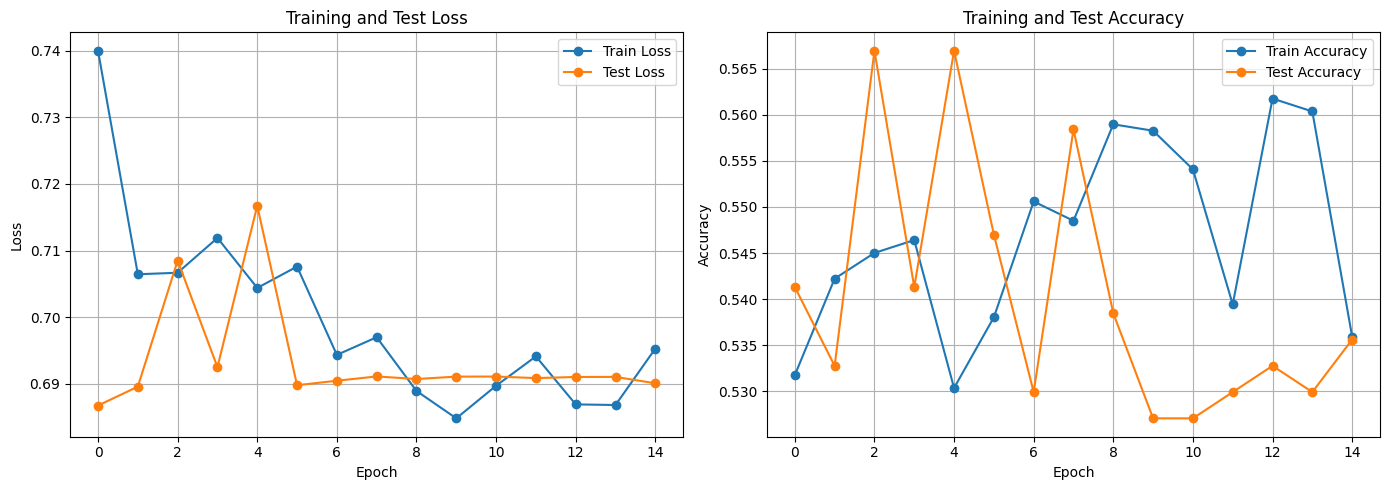

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(test_losses, label='Test Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accuracies, label='Train Accuracy', marker='o')
ax2.plot(test_accuracies, label='Test Accuracy', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 11. Model Evaluation

Calculate detailed metrics on the test set.

In [11]:
# Get predictions on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print('Test Set Metrics:')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Test Set Metrics:
Accuracy: 0.5356
Precision: 0.5161
Recall: 0.5356
F1-Score: 0.5020


## 12. Confusion Matrix

Visualize classification performance by orientation.

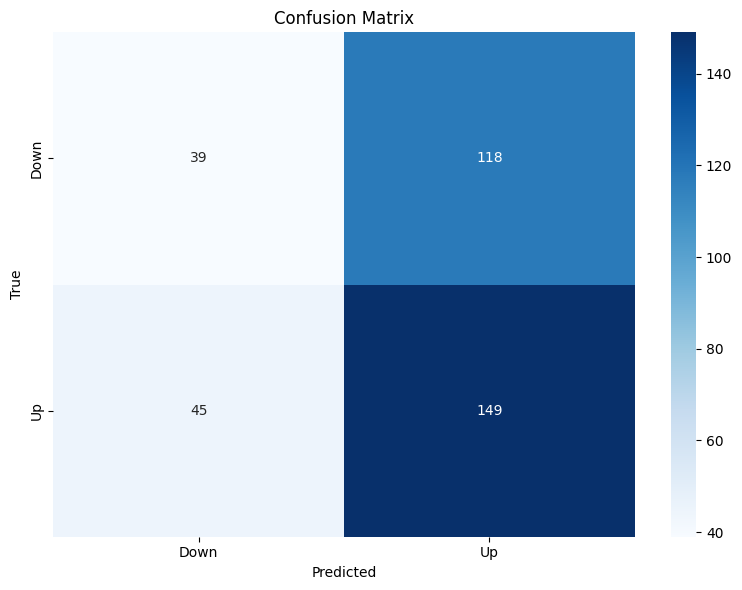


Per-class Performance:
Down: Precision=0.4643, Recall=0.2484
Up: Precision=0.5581, Recall=0.7680


In [12]:
cm = confusion_matrix(all_labels, all_preds)
classes = ['Down', 'Up']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Print per-class metrics
print('\nPer-class Performance:')
for idx, class_name in enumerate(classes):
    TP = cm[idx, idx]
    FP = cm[:, idx].sum() - TP
    FN = cm[idx, :].sum() - TP
    precision_class = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_class = TP / (TP + FN) if (TP + FN) > 0 else 0
    print(f'{class_name}: Precision={precision_class:.4f}, Recall={recall_class:.4f}')

## 13. Visualize Predictions

Display sample predictions with ground truth labels.

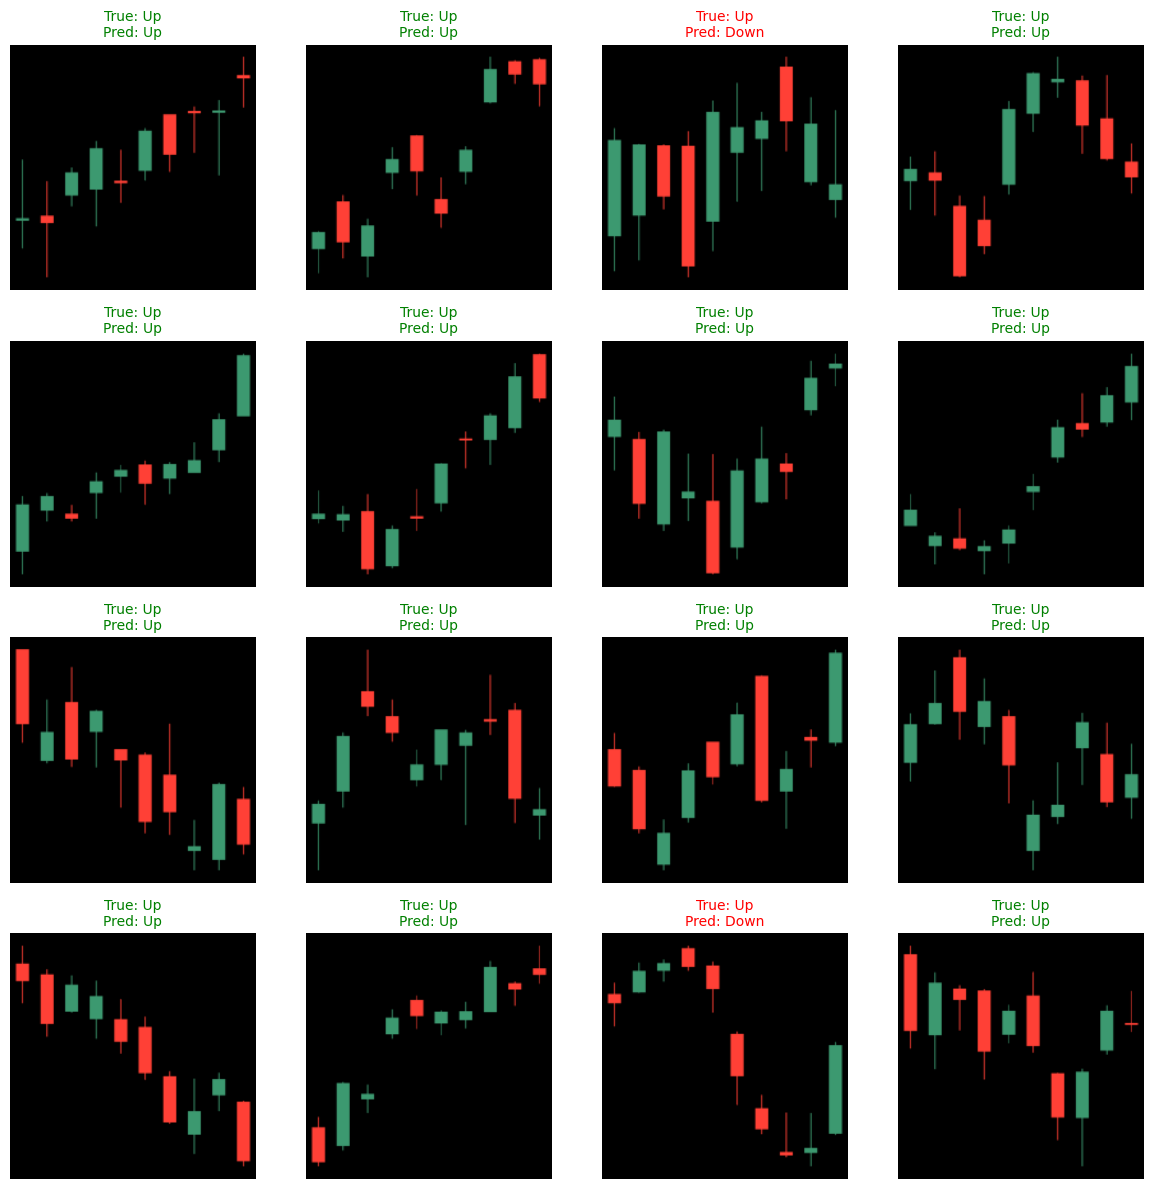

In [13]:
# Get a batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = torch.max(outputs, 1)

# Visualize
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
classes = ['Down', 'Up']

# Denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

for idx in range(min(16, len(images))):
    ax = axes[idx // 4, idx % 4]
    img = images[idx].cpu() * std + mean
    img = img.clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0))
    
    true_label = classes[labels[idx]]
    pred_label = classes[preds[idx].cpu()]
    color = 'green' if true_label == pred_label else 'red'
    
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 14. Results Summary

### Key Findings:
- The model achieved a test accuracy of **53.56%** on candle orientation classification.
- Overall performance metrics show the model struggles with this binary classification task, with an F1-score of 0.5020 indicating modest predictive power.
- Training curves reveal high variance and instability, suggesting the model has difficulty generalizing to the test set.

### Model Performance Analysis:

**Overall Metrics:**
- Accuracy: 53.56% (barely better than random guessing at 50%)
- Precision: 0.5161
- Recall: 0.5356
- F1-Score: 0.5020

**Per-Class Performance:**
- **Down**: Precision=0.4643, Recall=0.2484
  - The model performs poorly on "Down" candles, correctly identifying only 24.84% of them
  - High false positive rate (many Up predictions are actually Down)
  
- **Up**: Precision=0.5581, Recall=0.7680
  - Better at identifying "Up" candles with 76.80% recall
  - However, 56% of predicted "Up" candles are actually correct

**Confusion Matrix Insights:**
- Down class: 39 correct predictions, 118 misclassified as Up
- Up class: 149 correct predictions, 45 misclassified as Down
- The model has a strong bias toward predicting "Up", especially evident in the high rate of Down samples being misclassified as Up (118 out of 157 Down samples)

### Challenges Identified:
1. **Class Imbalance Bias**: The model learned to predict "Up" more frequently, achieving higher recall for that class at the expense of Down classification
2. **Training Instability**: The training curves show significant fluctuations in both loss and accuracy, indicating the model struggles to find stable learned representations
3. **Limited Discriminative Features**: The visual differences between Up and Down candles may be subtle or inconsistent, making binary classification difficult

### Recommendations for Improvement:
- **Apply class weighting** during training to penalize misclassification of the Down class more heavily
- **Use data augmentation more aggressively** (rotation, mirroring) to increase training diversity
- **Experiment with deeper architectures** (ResNet50, EfficientNet) for better feature extraction
- **Increase training data** or apply synthetic data generation techniques
- **Adjust learning rate and optimizer parameters** to stabilize training convergence
- **Implement early stopping** based on validation metric to prevent overfitting
- **Collect more balanced training data** if possible to address the class imbalance